# AerisPlane — Weight Buildup Tutorial

This notebook demonstrates the `weights` module: estimating aircraft mass from geometry and materials, overriding components with measured values, and interpreting the results.

**What the weights module does:**
1. Walks the aircraft definition (wings, fuselage, propulsion, servos, payload)
2. Estimates each component's mass from geometry + material properties
3. Computes total mass, center of gravity (CG), inertia tensor, and wing loading
4. Lets you override any component with a measured value from CAD or a physical scale

In [1]:
import aerisplane as ap
from aerisplane import weights
from aerisplane.weights.result import ComponentOverride
from aerisplane.catalog.materials import petg, pla_lw, carbon_fiber_tube
import numpy as np

## 1. Define a 3D-Printed Aircraft

We'll build a small trainer-style aircraft with:
- **Main wing:** 1.5 m span, PETG printed skin, carbon fiber tube spar
- **H-tail and V-tail:** smaller, same construction
- **Fuselage:** PETG printed shell
- **Propulsion:** brushless motor, 10x6 prop, 4S 2200 mAh LiPo, 30A ESC
- **Servos:** 24g digital servos on ailerons and elevator

In [2]:
# --- Structural definitions ---
# Carbon fiber tube spar: 12mm OD, 1.5mm wall
cf_spar = ap.Spar(
    position=0.25,  # at quarter-chord
    material=carbon_fiber_tube,
    section=ap.TubeSection(outer_diameter=0.012, wall_thickness=0.0015),
)

# PETG printed skin: 0.8mm wall (2 perimeters)
petg_skin = ap.Skin(material=petg, thickness=0.8e-3)

# Lighter skin for tail surfaces
petg_skin_thin = ap.Skin(material=petg, thickness=0.6e-3)

# Smaller spar for tail
cf_spar_tail = ap.Spar(
    position=0.25,
    material=carbon_fiber_tube,
    section=ap.TubeSection(outer_diameter=0.008, wall_thickness=0.001),
)

print(f"Main spar mass/length: {cf_spar.mass_per_length() * 1000:.1f} g/m")
print(f"Tail spar mass/length: {cf_spar_tail.mass_per_length() * 1000:.1f} g/m")
print(f"PETG skin mass/area:   {petg_skin.mass_per_area() * 1000:.2f} g/m² = {petg_skin.mass_per_area() * 10:.2f} g/dm²")

Main spar mass/length: 79.2 g/m
Tail spar mass/length: 35.2 g/m
PETG skin mass/area:   1016.00 g/m² = 10.16 g/dm²


In [3]:
# --- Servo ---
servo_24g = ap.Servo(name="Emax ES3004", torque=3.5, speed=300, voltage=6.0, mass=0.024)

# --- Main wing: 1.5m span, tapered ---
main_wing = ap.Wing(
    name="main_wing",
    xsecs=[
        ap.WingXSec(xyz_le=[0.10, 0.0, 0.0], chord=0.28, twist=2.0,
                     airfoil=ap.Airfoil("naca2412"), spar=cf_spar, skin=petg_skin),
        ap.WingXSec(xyz_le=[0.13, 0.75, 0.04], chord=0.16, twist=0.0,
                     airfoil=ap.Airfoil("naca2412"), spar=cf_spar, skin=petg_skin),
    ],
    symmetric=True,
    control_surfaces=[
        ap.ControlSurface(name="aileron", span_start=0.55, span_end=0.95,
                          chord_fraction=0.25, servo=servo_24g),
    ],
)

# --- Horizontal tail ---
h_tail = ap.Wing(
    name="htail",
    xsecs=[
        ap.WingXSec(xyz_le=[0.78, 0.0, 0.05], chord=0.12,
                     airfoil=ap.Airfoil("naca0010"), spar=cf_spar_tail, skin=petg_skin_thin),
        ap.WingXSec(xyz_le=[0.80, 0.25, 0.05], chord=0.08,
                     airfoil=ap.Airfoil("naca0010"), spar=cf_spar_tail, skin=petg_skin_thin),
    ],
    symmetric=True,
    control_surfaces=[
        ap.ControlSurface(name="elevator", span_start=0.1, span_end=0.9,
                          chord_fraction=0.35, servo=servo_24g),
    ],
)

# --- Vertical tail ---
v_tail = ap.Wing(
    name="vtail",
    xsecs=[
        ap.WingXSec(xyz_le=[0.76, 0.0, 0.05], chord=0.14,
                     airfoil=ap.Airfoil("naca0008"), spar=cf_spar_tail, skin=petg_skin_thin),
        ap.WingXSec(xyz_le=[0.80, 0.0, 0.20], chord=0.08,
                     airfoil=ap.Airfoil("naca0008"), spar=cf_spar_tail, skin=petg_skin_thin),
    ],
    symmetric=False,
    control_surfaces=[
        ap.ControlSurface(name="rudder", span_start=0.2, span_end=0.9,
                          chord_fraction=0.35, servo=servo_24g),
    ],
)

print(f"Main wing:  span={main_wing.span():.3f} m, area={main_wing.area():.4f} m²")
print(f"H-tail:     span={h_tail.span():.3f} m, area={h_tail.area():.4f} m²")
print(f"V-tail:     span={v_tail.span():.3f} m, area={v_tail.area():.4f} m²")

Main wing:  span=1.500 m, area=0.3300 m²
H-tail:     span=0.500 m, area=0.0500 m²
V-tail:     span=0.000 m, area=0.0000 m²


In [4]:
# --- Fuselage: PETG printed shell ---
fuselage = ap.Fuselage(
    name="fuselage",
    xsecs=[
        ap.FuselageXSec(x=0.00, radius=0.015),
        ap.FuselageXSec(x=0.08, radius=0.045),
        ap.FuselageXSec(x=0.25, radius=0.055),
        ap.FuselageXSec(x=0.65, radius=0.055),
        ap.FuselageXSec(x=0.85, radius=0.030),
        ap.FuselageXSec(x=1.00, radius=0.012),
    ],
    material=petg,
    wall_thickness=1.2e-3,  # 3 perimeters at 0.4mm
)

# --- Propulsion ---
motor = ap.Motor(name="SunnySky X2212-1400kv", kv=1400, resistance=0.065,
                 no_load_current=0.7, max_current=25.0, mass=0.056)
prop = ap.Propeller(diameter=0.254, pitch=0.152, mass=0.018)  # 10x6
battery = ap.Battery(name="Tattu 4S 2200mAh", capacity_ah=2.2, nominal_voltage=14.8,
                     cell_count=4, c_rating=45, mass=0.245, internal_resistance=0.015)
esc = ap.ESC(name="Hobbywing 30A", max_current=30, mass=0.028)

propulsion = ap.PropulsionSystem(
    motor=motor, propeller=prop, battery=battery, esc=esc,
    position=np.array([0.95, 0.0, 0.0]),  # motor at nose
)

# --- Payload (flight controller + receiver) ---
payload = ap.Payload(mass=0.045, cg=np.array([0.30, 0.0, 0.0]), name="avionics")

# --- Assemble ---
aircraft = ap.Aircraft(
    name="Trainer-1500",
    wings=[main_wing, h_tail, v_tail],
    fuselages=[fuselage],
    propulsion=propulsion,
    payload=payload,
)

print(f"Aircraft: {aircraft.name}")
print(f"Ref area: {aircraft.reference_area():.4f} m² ({aircraft.reference_area() * 100:.1f} dm²)")

Aircraft: Trainer-1500
Ref area: 0.3300 m² (33.0 dm²)


## 2. Run the Weight Buildup

`weights.analyze()` walks the aircraft and computes every component's mass from geometry + material properties.

In [5]:
result = weights.analyze(aircraft)
print(result.report())

AerisPlane Weight Buildup
Component                 Mass [g]  CG_x [mm]  CG_z [mm] Source         %
---------------------------------------------------------------------------
main_wing_skin               672.0      203.0       20.0 computed    30.4
fuselage_shell               426.6      464.4        0.0 computed    19.3
main_wing_ribs               278.2      203.0       20.0 computed    12.6
battery                      245.0      950.0        0.0 computed    11.1
main_wing_spar               119.0      170.0       20.0 computed     5.4
htail_skin                    76.4      830.0       50.0 computed     3.5
motor                         56.0      950.0        0.0 computed     2.5
fasteners                     54.0      582.7       45.8 computed     2.4
avionics                      45.0      300.0        0.0 computed     2.0
esc                           28.0      950.0        0.0 computed     1.3
vtail_skin                    26.0      824.0      125.0 computed     1.2
aileron_se

In [6]:
# Access individual values
print(f"Total mass:     {result.total_mass * 1000:.1f} g")
print(f"CG position:    x={result.cg[0] * 1000:.1f} mm, z={result.cg[2] * 1000:.1f} mm")
print(f"Wing loading:   {result.wing_loading:.1f} g/dm²")
print(f"Ixx (roll):     {result.inertia_tensor[0, 0]:.6f} kg·m²")
print(f"Iyy (pitch):    {result.inertia_tensor[1, 1]:.6f} kg·m²")
print(f"Izz (yaw):      {result.inertia_tensor[2, 2]:.6f} kg·m²")

Total mass:     2207.2 g
CG position:    x=438.8 mm, z=18.5 mm
Wing loading:   66.9 g/dm²
Ixx (roll):     0.017444 kg·m²
Iyy (pitch):    0.190943 kg·m²
Izz (yaw):      0.205989 kg·m²


## 3. Visualize the Result

`.plot()` gives a combined mass breakdown bar chart and side-view CG diagram.
Additional plot methods provide focused views:
- `.plot_distribution()` — donut/ring chart of mass fractions
- `.plot_cg()` — standalone CG bubble diagram with more vertical space
- `.plot_cg_bars()` — bar chart of component CG x-positions

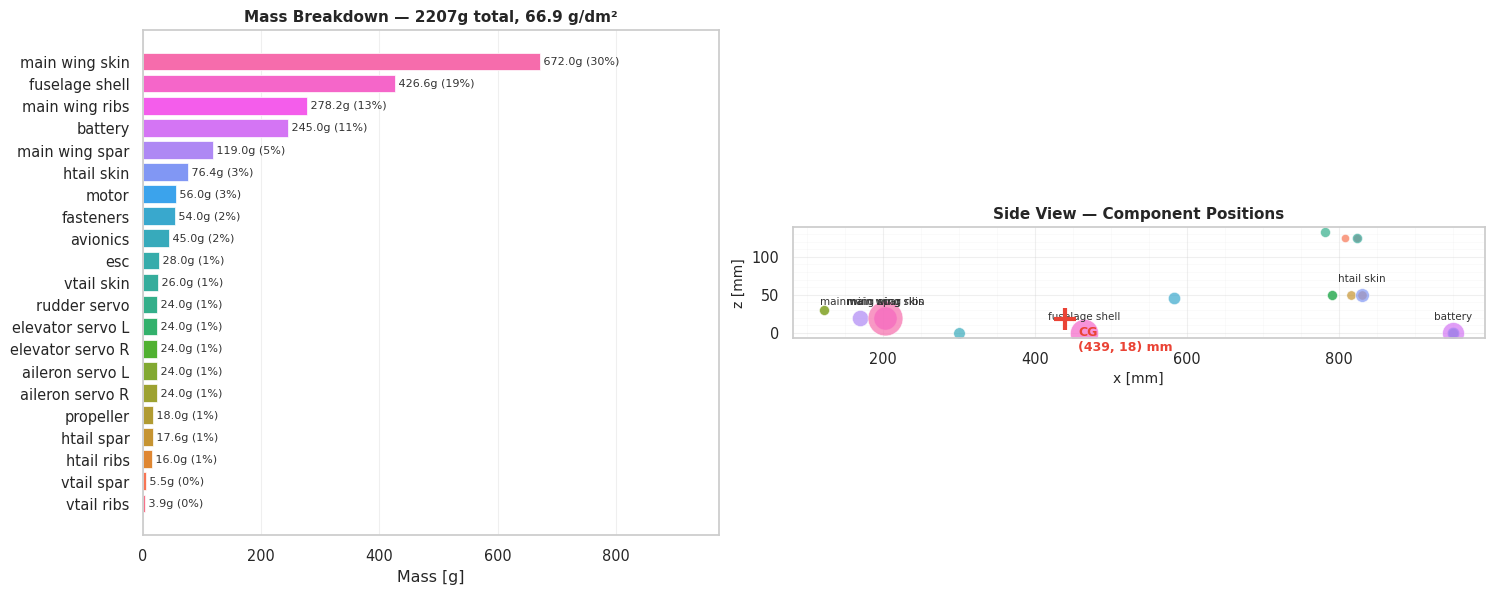

In [7]:
%matplotlib inline
fig = result.plot()

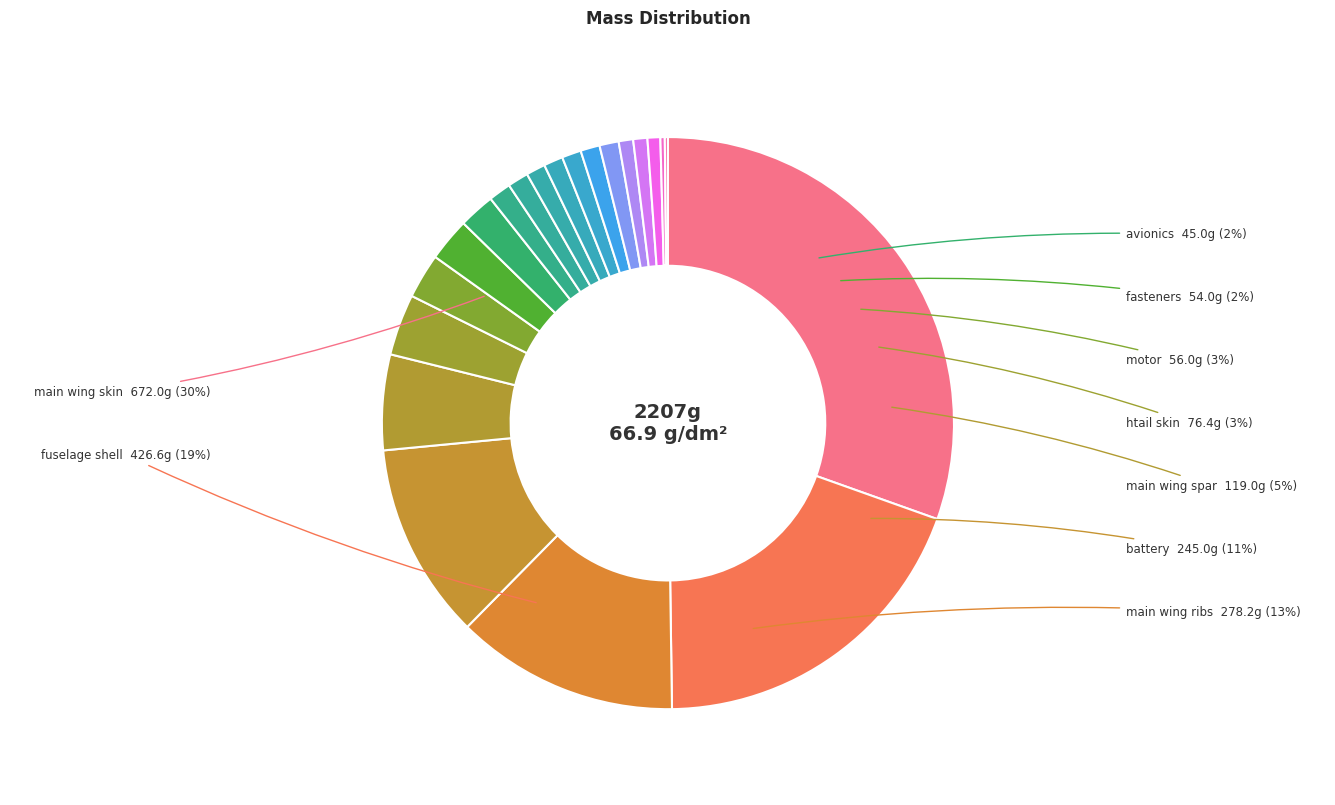

In [8]:
# Donut chart — mass distribution with callout labels
fig = result.plot_distribution()

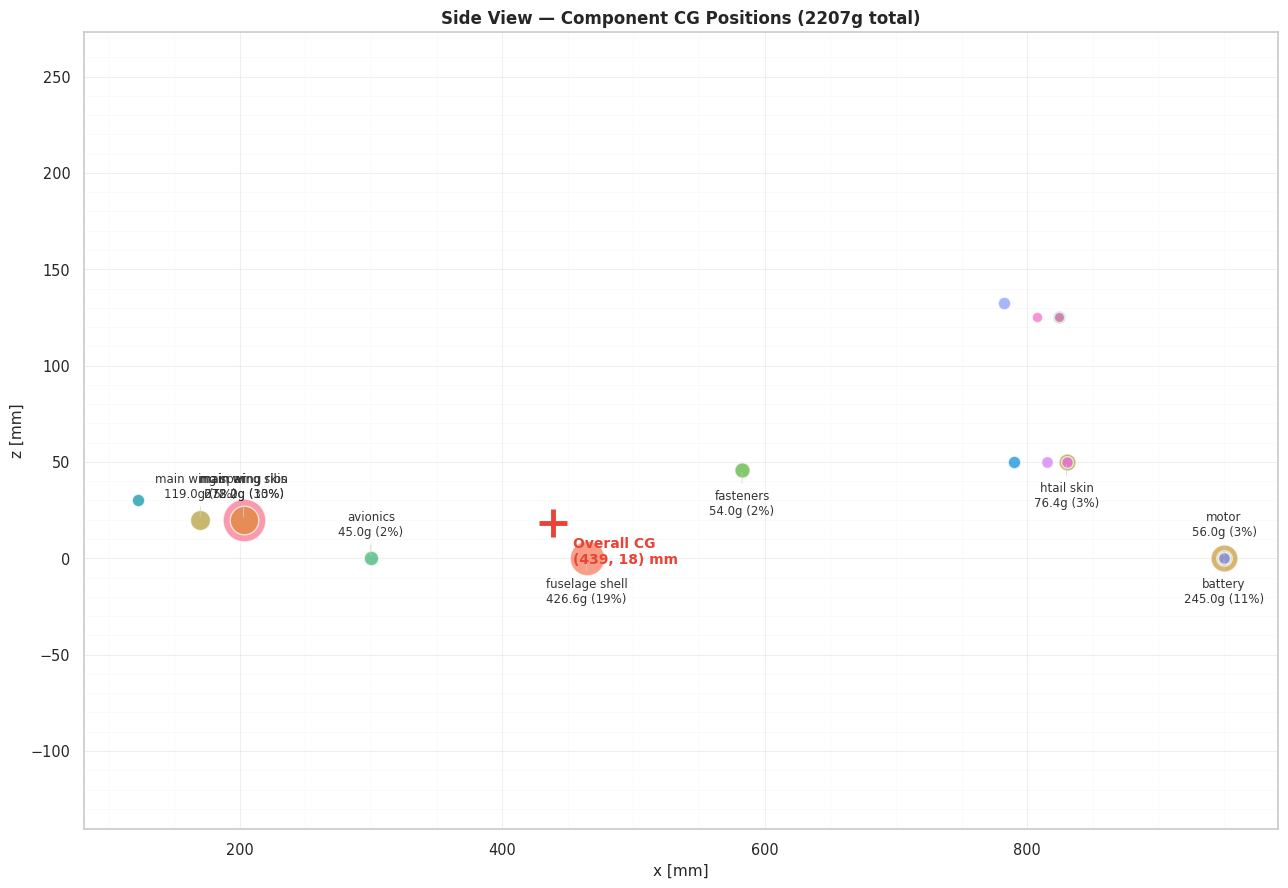

In [9]:
# Side-view CG bubble diagram — component positions with mass-proportional bubbles
fig = result.plot_cg()

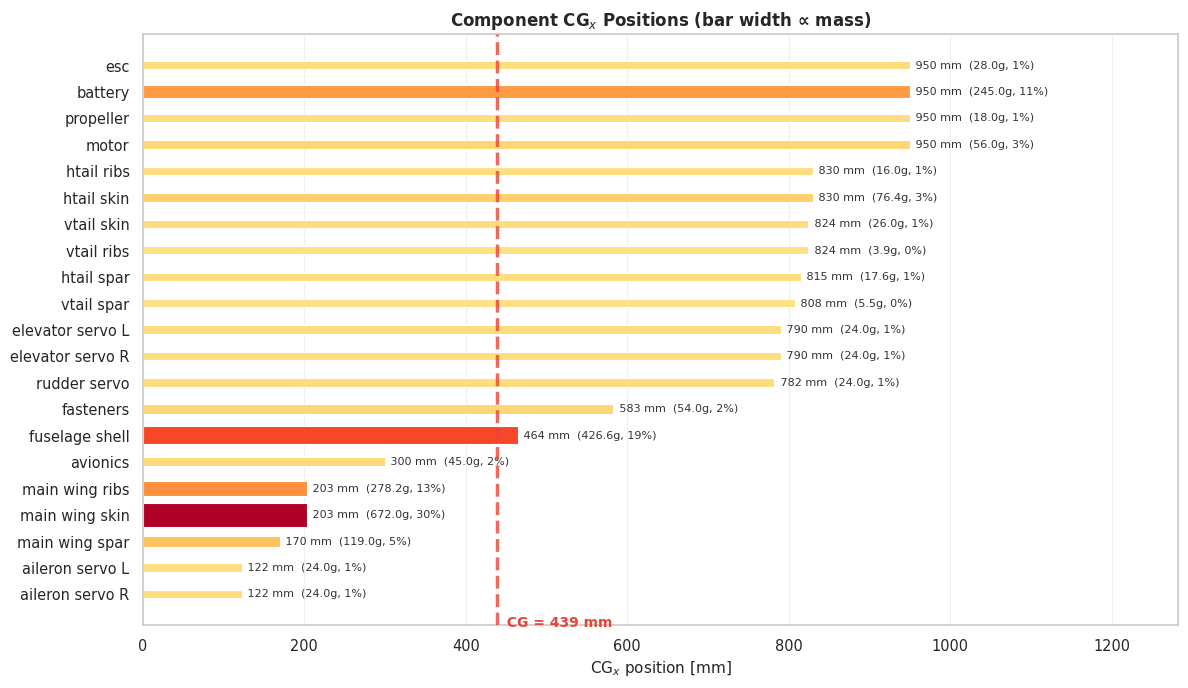

In [10]:
# CG position bar chart — where each component sits along the x-axis
fig = result.plot_cg_bars()

## 4. Override with Measured Values

As your build progresses, you can replace computed estimates with real measurements.
Overrides can:
- **Replace** an existing component (e.g., you weighed the printed wing)
- **Add** a new component the buildup doesn't know about (e.g., GPS, receiver, wiring)

In [11]:
# Scenario: you printed the wing and weighed it at 165g (heavier than estimated),
# and you want to add components the buildup doesn't track.
result_measured = weights.analyze(aircraft, overrides={
    # Replace: printed wing skin came out heavier than estimated
    "main_wing_skin": ComponentOverride(mass=0.165, cg=np.array([0.19, 0.0, 0.02])),
    # Replace: battery is positioned forward for CG balance
    "battery": ComponentOverride(mass=0.245, cg=np.array([0.22, 0.0, -0.01])),
    # Add: GPS module mounted on top of fuselage
    "gps_module": ComponentOverride(mass=0.025, cg=np.array([0.30, 0.0, 0.06])),
    # Add: RC receiver
    "receiver": ComponentOverride(mass=0.012, cg=np.array([0.35, 0.0, 0.0])),
    # Add: wiring harness estimate
    "wiring": ComponentOverride(mass=0.030, cg=np.array([0.40, 0.0, 0.0])),
})

print(result_measured.report())

AerisPlane Weight Buildup
Component                 Mass [g]  CG_x [mm]  CG_z [mm] Source         %
---------------------------------------------------------------------------
fuselage_shell               426.6      464.4        0.0 computed    24.1
main_wing_ribs               278.2      203.0       20.0 computed    15.7
battery                      245.0      220.0      -10.0 override    13.9
main_wing_skin               165.0      190.0       20.0 override     9.3
main_wing_spar               119.0      170.0       20.0 computed     6.7
htail_skin                    76.4      830.0       50.0 computed     4.3
motor                         56.0      950.0        0.0 computed     3.2
fasteners                     54.0      582.7       45.8 computed     3.1
avionics                      45.0      300.0        0.0 computed     2.5
wiring                        30.0      400.0        0.0 override     1.7
esc                           28.0      950.0        0.0 computed     1.6
vtail_skin

## 5. Compare Estimated vs. Measured

See how overrides shift the CG and total mass.

In [12]:
print(f"{'':30s} {'Estimated':>12s} {'Measured':>12s}")
print(f"{'-'*56}")
print(f"{'Total mass [g]':30s} {result.total_mass*1000:>12.1f} {result_measured.total_mass*1000:>12.1f}")
print(f"{'CG_x [mm]':30s} {result.cg[0]*1000:>12.1f} {result_measured.cg[0]*1000:>12.1f}")
print(f"{'CG_z [mm]':30s} {result.cg[2]*1000:>12.1f} {result_measured.cg[2]*1000:>12.1f}")
print(f"{'Wing loading [g/dm²]':30s} {result.wing_loading:>12.1f} {result_measured.wing_loading:>12.1f}")

# How far did CG move?
cg_shift = (result_measured.cg - result.cg) * 1000
print(f"\nCG shift: dx={cg_shift[0]:+.1f} mm, dz={cg_shift[2]:+.1f} mm")

# CG as % of MAC
mac = main_wing.mean_aerodynamic_chord()
mac_le_x = main_wing.mean_aerodynamic_chord_le()[0]
cg_pct_est = (result.cg[0] - mac_le_x) / mac * 100
cg_pct_meas = (result_measured.cg[0] - mac_le_x) / mac * 100
print(f"CG as % MAC: estimated={cg_pct_est:.1f}%, measured={cg_pct_meas:.1f}%")

                                  Estimated     Measured
--------------------------------------------------------
Total mass [g]                       2207.2       1767.2
CG_x [mm]                             438.8        400.8
CG_z [mm]                              18.5         16.8
Wing loading [g/dm²]                   66.9         53.6

CG shift: dx=-38.0 mm, dz=-1.7 mm
CG as % MAC: estimated=138.7%, measured=122.6%


## 6. Explore the Component Breakdown

You can iterate over components, filter by source, or inspect individual entries.

In [13]:
# Which components are overridden vs computed?
for comp in result_measured.components.values():
    tag = " <-- MEASURED" if comp.source == "override" else ""
    print(f"  {comp.name:<24s} {comp.mass*1000:6.1f} g  ({comp.source}){tag}")

print(f"\n{sum(1 for c in result_measured.components.values() if c.source == 'override')} overridden, "
      f"{sum(1 for c in result_measured.components.values() if c.source == 'computed')} computed")

  main_wing_spar            119.0 g  (computed)
  main_wing_skin            165.0 g  (override) <-- MEASURED
  main_wing_ribs            278.2 g  (computed)
  htail_spar                 17.6 g  (computed)
  htail_skin                 76.4 g  (computed)
  htail_ribs                 16.0 g  (computed)
  vtail_spar                  5.5 g  (computed)
  vtail_skin                 26.0 g  (computed)
  vtail_ribs                  3.9 g  (computed)
  fuselage_shell            426.6 g  (computed)
  motor                      56.0 g  (computed)
  propeller                  18.0 g  (computed)
  battery                   245.0 g  (override) <-- MEASURED
  esc                        28.0 g  (computed)
  aileron_servo_R            24.0 g  (computed)
  aileron_servo_L            24.0 g  (computed)
  elevator_servo_R           24.0 g  (computed)
  elevator_servo_L           24.0 g  (computed)
  rudder_servo               24.0 g  (computed)
  fasteners                  54.0 g  (computed)
  avionics    

## 7. Material Comparison

How does switching from PETG to PLA-LW (lightweight foaming PLA) affect wing skin mass?

In [14]:
# Build a second wing with PLA-LW skin
pla_lw_skin = ap.Skin(material=pla_lw, thickness=0.8e-3)

main_wing_lw = ap.Wing(
    name="main_wing",
    xsecs=[
        ap.WingXSec(xyz_le=[0.10, 0.0, 0.0], chord=0.28, twist=2.0,
                     airfoil=ap.Airfoil("naca2412"), spar=cf_spar, skin=pla_lw_skin),
        ap.WingXSec(xyz_le=[0.13, 0.75, 0.04], chord=0.16, twist=0.0,
                     airfoil=ap.Airfoil("naca2412"), spar=cf_spar, skin=pla_lw_skin),
    ],
    symmetric=True,
    control_surfaces=main_wing.control_surfaces,
)

aircraft_lw = ap.Aircraft(
    name="Trainer-1500 (PLA-LW)",
    wings=[main_wing_lw, h_tail, v_tail],
    fuselages=[fuselage],
    propulsion=propulsion,
    payload=payload,
)

result_lw = weights.analyze(aircraft_lw)

# Compare
skin_petg = result.components["main_wing_skin"].mass * 1000
skin_lw = result_lw.components["main_wing_skin"].mass * 1000
print(f"Wing skin mass (PETG):   {skin_petg:.1f} g")
print(f"Wing skin mass (PLA-LW): {skin_lw:.1f} g")
print(f"Saving:                  {skin_petg - skin_lw:.1f} g ({(1 - skin_lw/skin_petg)*100:.0f}%)")
print(f"\nTotal mass (PETG):   {result.total_mass*1000:.1f} g  |  WL={result.wing_loading:.1f} g/dm²")
print(f"Total mass (PLA-LW): {result_lw.total_mass*1000:.1f} g  |  WL={result_lw.wing_loading:.1f} g/dm²")

Wing skin mass (PETG):   672.0 g
Wing skin mass (PLA-LW): 423.3 g
Saving:                  248.7 g (37%)

Total mass (PETG):   2207.2 g  |  WL=66.9 g/dm²
Total mass (PLA-LW): 1855.6 g  |  WL=56.2 g/dm²
